# 09 — GMM Model Selection

**Goal:** Use AIC/BIC to select the optimal number of GMM components. GMMs allow *soft* clustering: each fighter gets probabilities across clusters (Hybrid Score = entropy of those probabilities). Lower AIC/BIC = better trade-off between fit and complexity.

**Input:** `ufc_modeling_data_final.csv`

**Takeaway:** The plot below shows AIC and BIC vs. number of components. The minimum point is the recommended k. BIC usually favors simpler models; AIC may suggest more components. We use k=3 and k=5 in notebook 10 for comparison.

In [1]:
# ========================================================================
# NOTEBOOK_CODE_HEADER v1
# File: 09_gmm_model_selection.ipynb | code cell index: 1
# Section (from markdown above): 09 — GMM Model Selection
# ------------------------------------------------------------------------
# Dependencies: see import statements below.
# Loads one or more CSV files (paths usually relative to notebooks/).
# Unsupervised clustering (K-Means or GMM).
# Standardizes features (mean 0, unit variance) where used.
# ========================================================================
# INLINE_WORKFLOW_SUMMARY v1
# Workflow summary (how to read this cell):
#   • CSV reads use paths relative to the notebooks/ working directory.
#   • Scaler is fit on training-like data only when a split is explicit.

# --- Core pipeline load for this notebook ---
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.mixture import GaussianMixture
from sklearn.preprocessing import StandardScaler
from scipy.stats import entropy

# Load Data
df = pd.read_csv('../data/processed/ufc_modeling_data_final.csv')

# Feature Selection (Same as K-Means for fair comparison)
features = [
    'Sig_Str_PM_Z',       # Striking Volume
    'Takedown_Att_PM_Z',  # Wrestling Aggression
    'Sub_Att_PM_Z',       # Grappling Threat
    'Control_Ratio_Z',    # Control Dominance
    'Distance_Ratio',     # Positional Preference
    'Clinch_Ratio',
    'Ground_Ratio'
]

# Prepare X
X = df[features].dropna()
print(f"Data ready: {X.shape[0]} fighters.")

# Standardize
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


Data ready: 1190 fighters.


## Model Selection (AIC/BIC)

### What are AIC and BIC?

**AIC (Akaike Information Criterion)** and **BIC (Bayesian Information Criterion)** are information-theoretic measures that balance **model fit** against **model complexity**. Both penalize overfitting: a more complex model (more parameters) must improve fit enough to justify the added complexity.

- **AIC** = $-2 \ln(\mathcal{L}) + 2k$, where $\mathcal{L}$ is the maximized likelihood and $k$ is the number of parameters. The term $2k$ penalizes each extra parameter.
- **BIC** = $-2 \ln(\mathcal{L}) + k \ln(n)$, where $n$ is sample size. BIC penalizes complexity more strongly than AIC when $n$ is large.

**Lower is better** for both. The model with the smallest AIC or BIC is preferred among the candidates.

### How do they apply to GMM and this project?

For a **Gaussian Mixture Model (GMM)**, the number of components $k$ is a key hyperparameter: it determines how many distinct fighting styles we assume exist. As $k$ increases, the model can fit the data more closely (better likelihood) but uses more parameters (more means, covariances, mixing weights) and risks overfitting noise.

- **AIC** tends to favor slightly more complex models; it may suggest a larger $k$ if the improvement in fit outweighs the penalty.
- **BIC** penalizes complexity more heavily and often favors simpler models (smaller $k$), especially with larger samples.

In our setting, we fit GMMs for $k = 1, 2, \ldots, 10$ on the fighter style-feature matrix and compute AIC/BIC for each. The optimal $k$ by each criterion gives us a data-driven recommendation for how many stylistic clusters to use. We then compare these with interpretability (e.g., in notebook 10) to choose a final $k$.

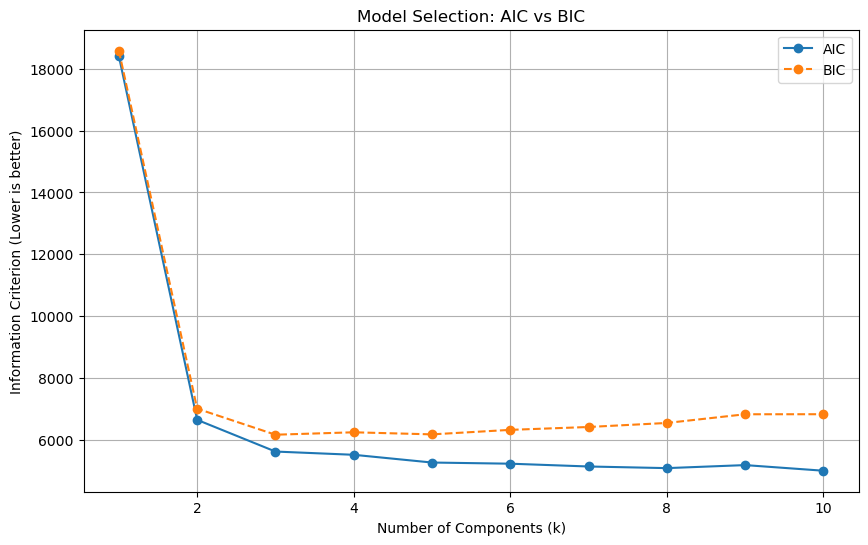

Optimal k (AIC): 10
Optimal k (BIC): 3


In [2]:
# ========================================================================
# NOTEBOOK_CODE_HEADER v1
# File: 09_gmm_model_selection.ipynb | code cell index: 3
# Section (from markdown above): Model Selection (AIC/BIC)
# ------------------------------------------------------------------------
# Builds matplotlib/seaborn figures.
# Unsupervised clustering (K-Means or GMM).
# ========================================================================
# INLINE_WORKFLOW_SUMMARY v1
# Workflow summary (how to read this cell):
#   • Follow the code top-to-bottom; prints document shapes and key counts.

n_components = range(1, 11)
aic_scores = []
bic_scores = []

for n in n_components:
    gmm = GaussianMixture(n_components=n, random_state=42, n_init=5)
    gmm.fit(X_scaled)
    aic_scores.append(gmm.aic(X_scaled))
    bic_scores.append(gmm.bic(X_scaled))

plt.figure(figsize=(10, 6))
plt.plot(n_components, aic_scores, label='AIC', marker='o')
plt.plot(n_components, bic_scores, label='BIC', marker='o', linestyle='--')
plt.title('Model Selection: AIC vs BIC')
plt.xlabel('Number of Components (k)')
plt.ylabel('Information Criterion (Lower is better)')
plt.legend()
plt.grid(True)
plt.show()

# Find minimums
best_k_aic = n_components[np.argmin(aic_scores)]
best_k_bic = n_components[np.argmin(bic_scores)]
print(f"Minimum k (AIC): {best_k_aic}")
print(f"Minimum k (BIC): {best_k_bic}")


**Interpretation:** The k where AIC (or BIC) reaches its minimum is the model-selection recommendation. Often AIC and BIC agree on a range (e.g. k=3–5); if they disagree, BIC favors fewer components. Use this to choose candidate k values for interpretability in notebook 10.

### Star examples
Notebook **10** fits GMM and lists cluster examples with **Hybrid Score**. Use the same names there to tie AIC/BIC choice to recognizable fighters.
